# Challenge: Analyzing Text about Data Science

In this example, let's do a simple exercise that covers all steps of a traditional data science process. You do not have to write any code, you can just click on the cells below to execute them and observe the result. As a challenge, you are encouraged to try this code out with different data. 

## Goal

In this lesson, we have been discussing different concepts related to Data Science. Let's try to discover more related concepts by doing some **text mining**. We will start with a text about Data Science, extract keywords from it, and then try to visualize the result.

As a text, I will use the page on Data Science from Wikipedia:

In [196]:
url = 'https://en.wikipedia.org/wiki/India'

## Step 1: Getting the Data

First step in every data science process is getting the data. We will use `requests` library to do that:

In [197]:
import requests

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
text = requests.get(url, headers=headers).content.decode('utf-8')
print(text[:1000])

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>India - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature

## Step 2: Transforming the Data

The next step is to convert the data into the form suitable for processing. In our case, we have downloaded HTML source code from the page, and we need to convert it into plain text.

There are many ways this can be done. We will use [BeautifulSoup](https://www.crummy.com/software/BeautifulSoup/), a popular Python library for parsing HTML. BeautifulSoup allows us to target specific HTML elements, so we can focus on the main article content from Wikipedia and reduce some navigation menus, sidebars, footers, and other irrelevant content (though some boilerplate text may still remain).

First, we need to install the BeautifulSoup library for HTML parsing:

In [198]:
import sys
!{sys.executable} -m pip install beautifulsoup4

In [199]:
import requests
from bs4 import BeautifulSoup

soup = BeautifulSoup(text, "html.parser")

def clean_wikipedia_content(content_node):
    selectors = [
        ".mw-jump-link",
        ".navbox",
        ".reflist",
        "sup.reference",
        ".mw-editsection",
        ".hatnote",
        ".metadata",
        ".infobox",
        "#toc",
        ".toc",
        ".sidebar",
        ".mw-empty-elt",
    ]

    for selector in selectors:
        for el in content_node.select(selector):
            el.decompose()

# Target actual Wikipedia article body
article = soup.select_one("#mw-content-text .mw-parser-output")

if article:

    paragraphs = article.find_all("p")

    article_text = []

    for p in paragraphs:
        para_text = p.get_text(separator=" ", strip=True)

        if para_text:
            article_text.append(para_text)

    final_text = "\n\n".join(article_text)

    print(final_text)
else:
    print("Could not find main article content.")

India , officially the Republic of India , [ j ] [ 19 ] is a country in South Asia .  It is the seventh-largest country by area ; the most populous country in the world [ 20 ] and, since its independence in 1947, the world's most populous democracy. [ 21 ] [ 22 ] [ 23 ] Bounded by the Indian Ocean on the south, the Arabian Sea on the southwest, and the Bay of Bengal on the southeast, it shares land borders with Pakistan to the west; [ k ] China , Nepal and Bhutan to the north; Bangladesh and Myanmar to the east. In the Indian Ocean, India is near Sri Lanka and the Maldives . Its Andaman and Nicobar Islands share a maritime border with Myanmar, Thailand and Indonesia .

Modern humans arrived on the Indian subcontinent from Africa no later than 55,000 years ago. [ 25 ] [ 26 ] [ 27 ] Their long occupation, predominantly in isolation as hunter-gatherers, has made the region highly diverse. [ 28 ] Settled life emerged on the subcontinent in the western margins of the Indus river basin 9,000

## Step 3: Getting Insights

The most important step is to turn our data into some form from which we can draw insights. In our case, we want to extract keywords from the text, and see which keywords are more meaningful.

We will use Python library called [RAKE](https://github.com/aneesha/RAKE) for keyword extraction. First, let's install this library in case it is not present: 

In [200]:
import sys
!{sys.executable} -m pip install nlp_rake

The main functionality is available from `Rake` object, which we can customize using some parameters. In our case, we will set the minimum length of a keyword to 5 characters, minimum frequency of a keyword in the document to 3, and maximum number of words in a keyword - to 2. Feel free to play around with other values and observe the result.

In [201]:
import nlp_rake
extractor = nlp_rake.Rake(max_words=2,min_freq=3,min_chars=5)
res = extractor.apply(final_text)
res

[('13th century', 4.0),
 ('prime minister', 4.0),
 ('prime ministers', 4.0),
 ('constituent assembly', 4.0),
 ('indian mathematics', 3.9761904761904763),
 ('western ghats', 3.8461538461538463),
 ('southeast asia', 3.833333333333333),
 ('urban areas', 3.8),
 ('mughal empire', 3.75),
 ('south asia', 3.7222222222222223),
 ('rural areas', 3.666666666666667),
 ('general elections', 3.571428571428571),
 ('indian subcontinent', 3.5317460317460316),
 ('united states', 3.4444444444444446),
 ('caste system', 3.3566433566433567),
 ("india's constitution", 3.313186813186813),
 ('peninsular india', 3.295774647887324),
 ('eastern india', 3.295774647887324),
 ('western india', 3.1419284940411703),
 ('millennium bce', 3.0952380952380953),
 ('south india', 3.0179968701095463),
 ('northern india', 2.962441314553991),
 ('north india', 2.595774647887324),
 ('empire', 1.75),
 ('south', 1.7222222222222223),
 ('central', 1.6666666666666667),
 ('state', 1.6666666666666667),
 ('government', 1.6428571428571428)


We obtained a list terms together with associated degree of importance. As you can see, the most relevant disciplines, such as machine learning and big data, are present in the list at top positions.

## Step 4: Visualizing the Result

People can interpret the data best in the visual form. Thus it often makes sense to visualize the data in order to draw some insights. We can use `matplotlib` library in Python to plot simple distribution of the keywords with their relevance:

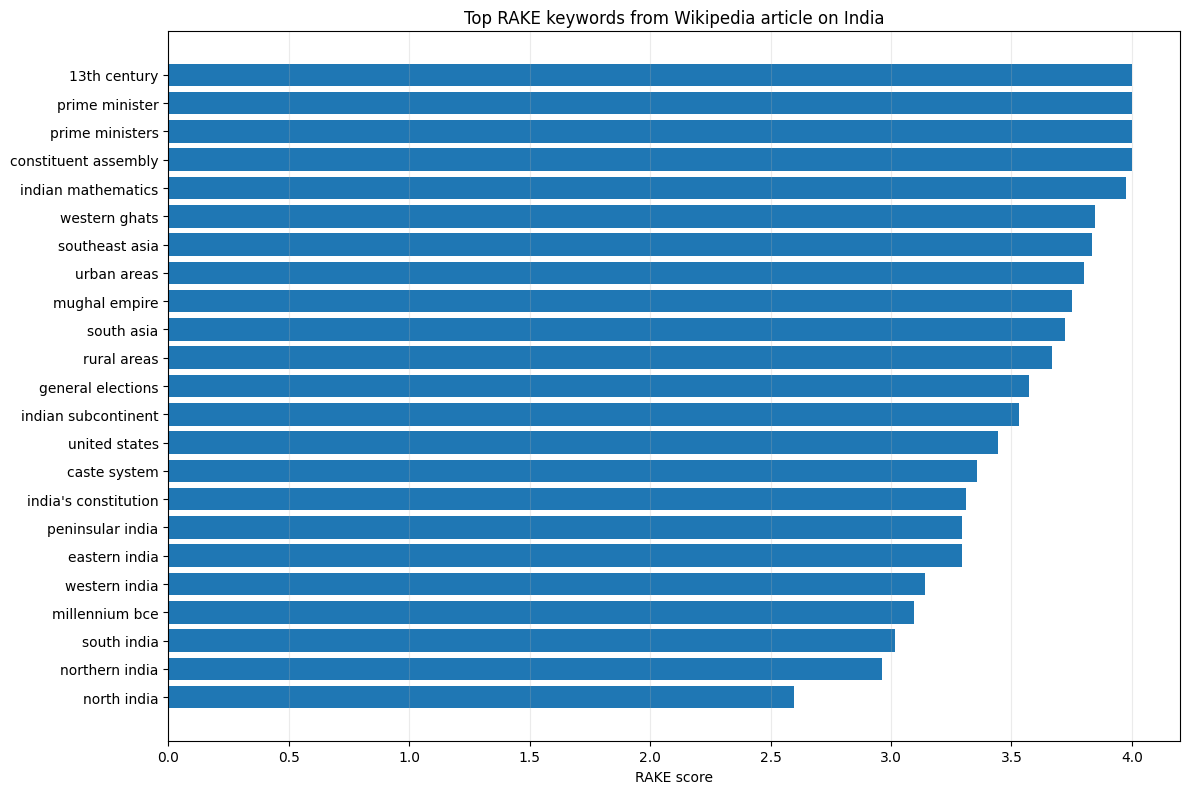

In [202]:
import matplotlib.pyplot as plt
from textwrap import wrap

def plot_keywords(pair_list, top_n=30, min_score=None, title="Top RAKE keywords"):
    # Clean + optionally filter
    data = [
        (keyword, float(score))
        for keyword, score in pair_list
        if keyword and (min_score is None or score >= min_score)
    ]

    # Sort by score and keep top N
    data = sorted(data, key=lambda x: x[1], reverse=True)[:top_n]

    if not data:
        print("No keywords to plot.")
        return

    keywords, scores = zip(*data)

    # Wrap long labels so they fit
    keywords = [
        "\n".join(wrap(keyword, width=30))
        for keyword in keywords
    ]

    # Reverse for barh so highest appears at top
    keywords = keywords[::-1]
    scores = scores[::-1]

    # Dynamic height based on number of bars
    plt.figure(figsize=(12, max(6, len(keywords) * 0.35)))

    plt.barh(keywords, scores)
    plt.xlabel("RAKE score")
    plt.title(title)
    plt.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

plot_keywords(res, top_n=30, min_score=2, title="Top RAKE keywords from Wikipedia article on India")

There is, however, even better way to visualize word frequencies - using **Word Cloud**. We will need to install another library to plot the word cloud from our keyword list.

In [203]:
!{sys.executable} -m pip install wordcloud

`WordCloud` object is responsible for taking in either original text, or pre-computed list of words with their frequencies, and returns and image, which can then be displayed using `matplotlib`:

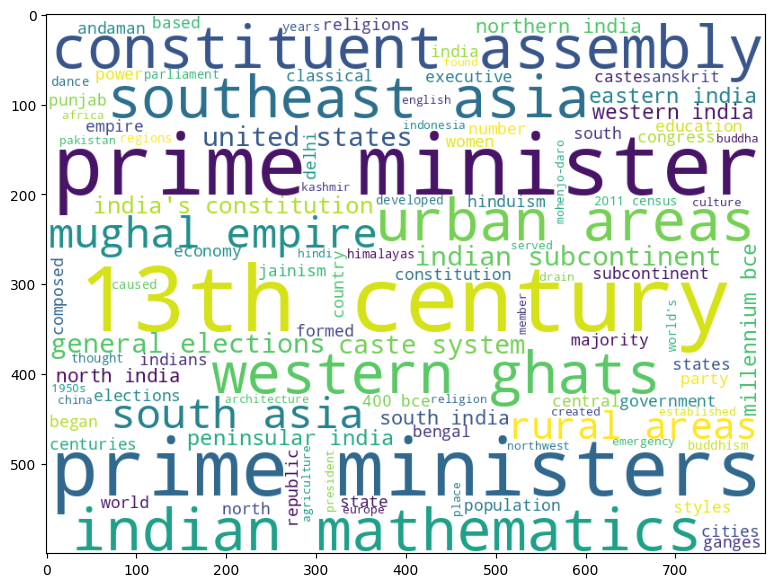

In [204]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(background_color='white',width=800,height=600)
plt.figure(figsize=(15,7))
plt.imshow(wc.generate_from_frequencies({ k:v for k,v in res }))

We can also pass in the original text to `WordCloud` - let's see if we are able to get similar result:

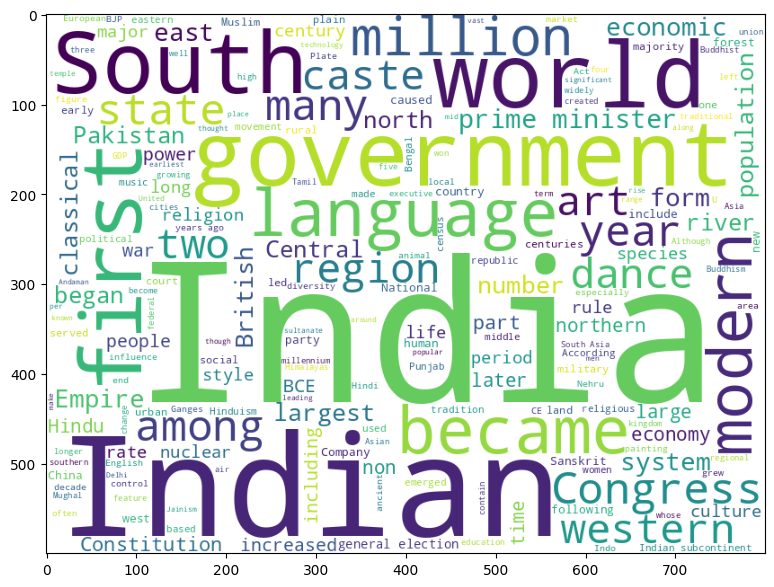

In [205]:
plt.figure(figsize=(15,7))
plt.imshow(wc.generate(final_text))

In [206]:
wc.generate(final_text).to_file('images/ds_wordcloud.png')

You can see that word cloud now looks more impressive, but it also contains a lot of noise (eg. unrelated words such as `Retrieved on`). Also, we get fewer keywords that consist of two words, such as *data scientist*, or *computer science*. This is because RAKE algorithm does much better job at selecting good keywords from text. This example illustrates the importance of data pre-processing and cleaning, because clear picture at the end will allow us to make better decisions.

In this exercise we have gone through a simple process of extracting some meaning from Wikipedia text, in the form of keywords and word cloud. This example is quite simple, but it demonstrates well all typical steps a data scientist will take when working with data, starting from data acquisition, up to visualization.

In our course we will discuss all those steps in detail. 